**Restaurant Review Sentiment Analysis**

The restaurant industry is a highly competitive market with a lot of players in it. One way in which restaurant can stand out is via their reviews on sites such as Yelp. By understanding whether a review is positive or negative, and what makes it positive or negative, or neutral, a restaurant can understand the issues or strengths that it has, and can act to correct them. In this notebook, we will explore Yelp data (reviews and business data) in order to create a model that can classify reviews of California restaurants by their sentiment. This will be done using NLP techniques and will end up with a set of models that can read a review and classify whether it is a good, neutral, or bad review.

In [ ]:
#!pip install nltk

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Creating a merged dataset for analysis**

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/yelp_data/yelp_academic_dataset_review.csv"
df = pd.read_csv(file_path)


In [ ]:
df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [ ]:
file_path = "/content/drive/My Drive/yelp_data/yelp_academic_dataset_business.csv"
df2 = pd.read_csv(file_path)

In [ ]:
# Isolate CA
caliBusn = df2[df2.state == 'CA']
len(caliBusn['categories'].unique())

4185

In [ ]:
caliBusn.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",NaN
26,noByYNtDLQAra9ccqxdfDw,H&M,827-833 State St,Santa Barbara,CA,93101,34.420209,-119.700460,3.0,24,1,"{'BusinessAcceptsCreditCards': 'True', 'BikePa...","Women's Clothing, Accessories, Children's Clot...","{'Monday': '11:0-18:0', 'Tuesday': '11:0-18:0'..."
85,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,"131 Anacapa St, Ste C",Santa Barbara,CA,93101,34.414445,-119.690672,4.0,389,1,"{'RestaurantsTakeOut': 'True', 'NoiseLevel': ""...","Food, Restaurants, Salad, Coffee & Tea, Breakf...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-14:0', '..."
91,nUqrF-h9S7myCcvNDecOvw,Iron Horse Auto Body,825 Cacique St,Santa Barbara,CA,93103,34.419620,-119.677032,4.5,32,1,"{'BusinessAcceptsCreditCards': 'True', 'WiFi':...","Towing, Automotive, Body Shops","{'Monday': '0:0-0:0', 'Tuesday': '8:0-17:0', '..."
120,bYjnX_J1bHZob10DoSFkqQ,Tinkle Belle Diaper Service,NaN,Santa Barbara,CA,93101,34.420334,-119.710749,5.0,17,1,"{'BusinessAcceptsCreditCards': 'True', 'ByAppo...","Parenting Classes, Maternity Wear, Fashion, Ed...","{'Monday': '0:0-0:0', 'Tuesday': '10:0-18:0', ..."


In [ ]:
# Only grab restaurants to look at
caliBusn_filtered = caliBusn[caliBusn['categories'].astype(str).str.lower().str.contains('restaurant', na=False)]

In [ ]:
# Create a dataset that contains all relevant data + the review itself
df_merged = df.merge(caliBusn_filtered, on='business_id', how='inner')

In [ ]:
df_merged.to_csv('/content/drive/My Drive/mergedData.csv', index=False)

**Text Preprocessing**

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/mergedData.csv"
df = pd.read_csv(file_path)


In [ ]:
# Basic EDA
df.describe()

,stars_x,useful,funny,cool,postal_code,latitude,longitude,stars_y,review_count,is_open
count,211748.000000,211748.000000,211748.000000,211748.000000,211748.000000,211748.000000,211748.000000,211748.000000,211748.000000,211748.00000
mean,3.937492,0.950314,0.386729,0.553379,93101.136606,34.422068,-119.717232,3.938625,653.785027,0.79197
std,1.343227,3.451377,2.155515,3.135253,40.845969,0.056574,0.077734,0.514233,731.111678,0.40590
min,1.000000,0.000000,0.000000,0.000000,93013.000000,34.385048,-120.083748,1.500000,5.000000,0.00000
25%,3.000000,0.000000,0.000000,0.000000,93101.000000,34.414340,-119.735834,3.500000,188.000000,1.00000
50%,4.000000,0.000000,0.000000,0.000000,93101.000000,34.420782,-119.700151,4.000000,387.000000,1.00000
75%,5.000000,1.000000,0.000000,0.000000,93109.000000,34.427943,-119.691322,4.500000,856.000000,1.00000
max,5.000000,181.000000,134.000000,184.000000,96161.000000,39.382812,-119.490740,5.000000,3834.000000,1.00000


In [ ]:
# Columns of interest
desiredColumns = ['text', 'stars_y', 'review_count', 'is_open']
df = df[desiredColumns]
df.head()

,text,stars_y,review_count,is_open
0,Had a party of 6 here for hibachi. Our waitres...,3.5,488,1
1,"Yes, this is the only sushi place in town. How...",3.0,167,1
2,"Great burgers,fries and salad! Burgers have a...",4.0,329,1
3,What a great addition to the Funk Zone! Grab ...,4.0,389,1
4,We were a bit weary about trying the Shellfish...,4.0,2404,1


In [ ]:
import string
df['text'] = df['text'].str.lower() #lowercase the text
df['text'] = df['text'].str.translate(str.maketrans('', '', string.punctuation)) #remove punctuation
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip() # remove extra spaces

<ipython-input-8-06738de0f7f6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].str.lower()
<ipython-input-8-06738de0f7f6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].str.translate(str.maketrans('', '', string.punctuation))
<ipython-input-8-06738de0f7f6>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# download
nltk.download('punkt_tab', force=True)
nltk.download('stopwords', force=True)
nltk.download('wordnet', force=True)
df['text'] = df['text'].apply(word_tokenize) # tokenize the words
stop_words = set(stopwords.words('english'))
df['text'] = df['text'].apply(lambda x: [word for word in x if word not in stop_words]) # remove stop words
lemmatizer = WordNetLemmatizer()
df['text'] = df['text'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x]) # lemmatize the words
df['text'] = df['text'].apply(lambda x: ' '.join(x)) # join the text back together
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,text,stars_y,review_count,is_open
0,party 6 hibachi waitress brought separate sush...,3.5,488,1
1,yes sushi place town however great youre cravi...,3.0,167,1
2,great burgersfries salad burger hint salt pepp...,4.0,329,1
3,great addition funk zone grab bite grab tastin...,4.0,389,1
4,bit weary trying shellfish company wharf often...,4.0,2404,1


In [ ]:
df.to_csv('/content/drive/My Drive/cleanedText.csv', index=False)

**Model Creation**

In [ ]:
file_path = "/content/drive/My Drive/cleanedText.csv"
df = pd.read_csv(file_path)

The class distribution if categorizing sentiment by 0-2, 3, 4-5 is very skewed with only 2000 entries in the Bad category if done this way. However, if categorized as 0-3, 3-4, 4-5, the distribution becomes better, with the smallest category now having 14000 entries. This means that we now have more data to work with, and can better account for the less frequently shown star rating.

In [ ]:
# Because the class distribution is not even, since our goal is to create a non-partial model, we want to create a set of data that is balanced to train our models on

from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Define sentiment labels
def categorize_sentiment(stars):
    if stars <= 3:
        return 0  # Bad
    elif stars <= 4:
        return 1  # Neutral
    else:
        return 2  # Good

# Apply sentiment categorization
df['sentimentByStar'] = df['stars_y'].apply(categorize_sentiment)


# Identify bad/neutral/good rows
df_bad = df[df['sentimentByStar'] == 0]
df_neutral = df[df['sentimentByStar'] == 1]
df_good = df[df['sentimentByStar'] == 2]

# Get the min count of the 3 categories so that we can create a balanced dataset
min_size = min(len(df_bad), len(df_neutral), len(df_good))

# Resample the data so that the train data is balanced
df_bad_balanced = resample(df_bad, replace=False, n_samples=min_size, random_state=42)
df_neutral_balanced = resample(df_neutral, replace=False, n_samples=min_size, random_state=42)
df_good_balanced = resample(df_good, replace=False, n_samples=min_size, random_state=42)

# Reform the balanced df

df_balanced = pd.concat([df_bad_balanced, df_neutral_balanced, df_good_balanced])

# Shuffle the order, just incase
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Stratified sampling to balance classes
X_train, X_test, y_train, y_test = train_test_split(df_balanced['text'], df_balanced['sentimentByStar'], test_size=0.2, stratify=df_balanced['sentimentByStar'], random_state=42)

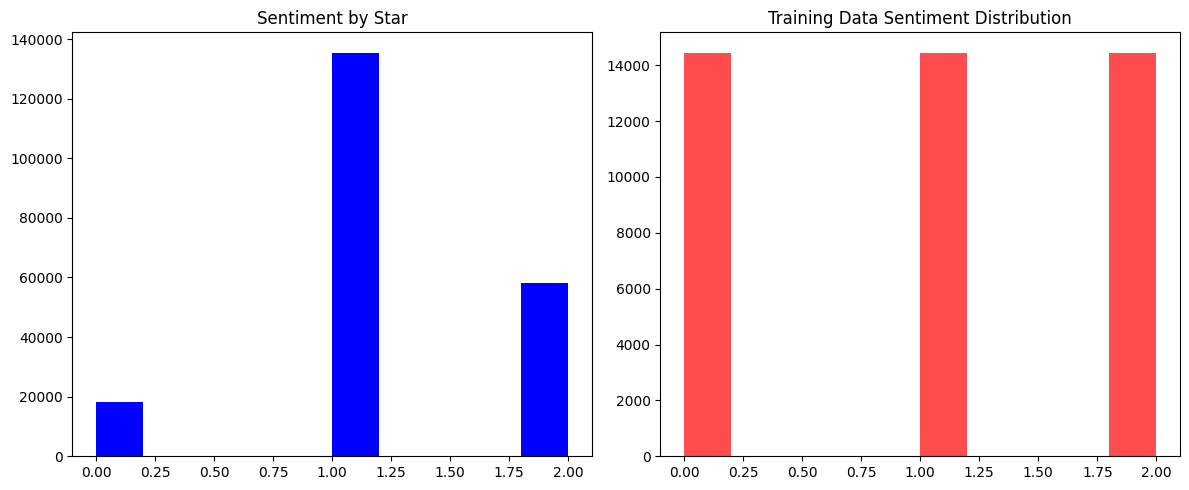

In [ ]:
# Plot Distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

axes[0].hist(df['sentimentByStar'], alpha=1, color='blue')
axes[0].set_title("Sentiment by Star")

axes[1].hist(y_train.dropna(), alpha=0.7, color='red')
axes[1].set_title("Training Data Sentiment Distribution")

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into TF-IDF vectors (we use tf-idf b/c it is more or less standard)
tfidf = TfidfVectorizer(max_features=5000)  # Use top 5000 words
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


**When training data, our main evaluation metric is accuracy BECAUSE we have balanced the classes in the dataset and therefore want to know in general, how right our model is. However, I also take a look at f1-score by class to see if the model is biased towards certain classes**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train logistic regression model
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_tfidf)

# Evaluate
lru = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy:  0.6582710582157025
Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      3613
           1       0.58      0.53      0.55      3613
           2       0.68      0.70      0.69      3613

    accuracy                           0.66     10839
   macro avg       0.65      0.66      0.66     10839
weighted avg       0.65      0.66      0.66     10839



In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid_lr = {
    'C': [0.1, 1, 10, 50],  # Regularization strength
    'solver': ['lbfgs', 'saga']  # Optimization algorithms
}

# Initialize model
lr = LogisticRegression(multi_class='multinomial', max_iter=1000)

# Perform Grid Search
grid_search_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search_lr.fit(X_train_tfidf, y_train)

# Best parameters and model
print("Best Parameters for Logistic Regression:", grid_search_lr.best_params_)
best_lr = grid_search_lr.best_estimator_

# Evaluate on test data
y_pred_lr = best_lr.predict(X_test_tfidf)
lro = accuracy_score(y_test, y_pred_lr)
print("Optimized Logistic Regression Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Optimized Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters for Logistic Regression: {'C': 1, 'solver': 'saga'}
Optimized Logistic Regression Accuracy:  0.6567949072792693
Optimized Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      3613
           1       0.58      0.53      0.55      3613
           2       0.68      0.69      0.69      3613

    accuracy                           0.66     10839
   macro avg       0.65      0.66      0.65     10839
weighted avg       0.65      0.66      0.65     10839



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_tfidf)

# Evaluate
rfu = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy:  0.5898145585386105
Random Forest Performance:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67      3613
           1       0.51      0.38      0.44      3613
           2       0.60      0.67      0.63      3613

    accuracy                           0.59     10839
   macro avg       0.58      0.59      0.58     10839
weighted avg       0.58      0.59      0.58     10839



In [ ]:
# Careful, it takes a while to run

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search_rf.fit(X_train_tfidf, y_train)

# Best parameters and model
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
best_rf = grid_search_rf.best_estimator_

# Evaluate on test data
rfo = accuracy_score(y_test, y_pred_rf)
y_pred_rf = best_rf.predict(X_test_tfidf)
print("Optimized Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Optimized Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Optimized Random Forest Accuracy:  0.59267460097795
Optimized Random Forest Performance:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67      3613
           1       0.52      0.37      0.44      3613
           2       0.60      0.69      0.64      3613

    accuracy                           0.59     10839
   macro avg       0.58      0.59      0.58     10839
weighted avg       0.58      0.59      0.58     10839



In [ ]:
from xgboost import XGBClassifier

# Train XGBoost model
xgb = XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss')
xgb.fit(X_train_tfidf, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test_tfidf)

# Evaluate
xgu = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy: ", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy:  0.6402804686779223
XGBoost Performance:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70      3613
           1       0.58      0.50      0.53      3613
           2       0.66      0.69      0.67      3613

    accuracy                           0.64     10839
   macro avg       0.64      0.64      0.64     10839
weighted avg       0.64      0.64      0.64     10839



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.5, 0.7, 1.0]
}

xgb = XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', use_label_encoder=False)

random_search_xgb = RandomizedSearchCV(xgb, param_distributions=param_grid_xgb, n_iter=10, cv=3, scoring='accuracy', verbose=2, n_jobs=-1, random_state=42)
random_search_xgb.fit(X_train_tfidf, y_train)

# Best parameters and model
print("Best Parameters for XGBoost:", random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

# Evaluate on test data
y_pred_xgb = best_xgb.predict(X_test_tfidf)
xgo = accuracy_score(y_test, y_pred_xgb)
print("Optimized XGBoost Accuracy: ", accuracy_score(y_test, y_pred_xgb))
print("Optimized XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:36:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters for XGBoost: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2}
Optimized XGBoost Accuracy:  0.6483992988283052
Optimized XGBoost Performance:
              precision    recall  f1-score   support

           0       0.69      0.74      0.71      3613
           1       0.57      0.52      0.54      3613
           2       0.67      0.69      0.68      3613

    accuracy                           0.65     10839
   macro avg       0.64      0.65      0.65     10839
weighted avg       0.64      0.65      0.65     10839



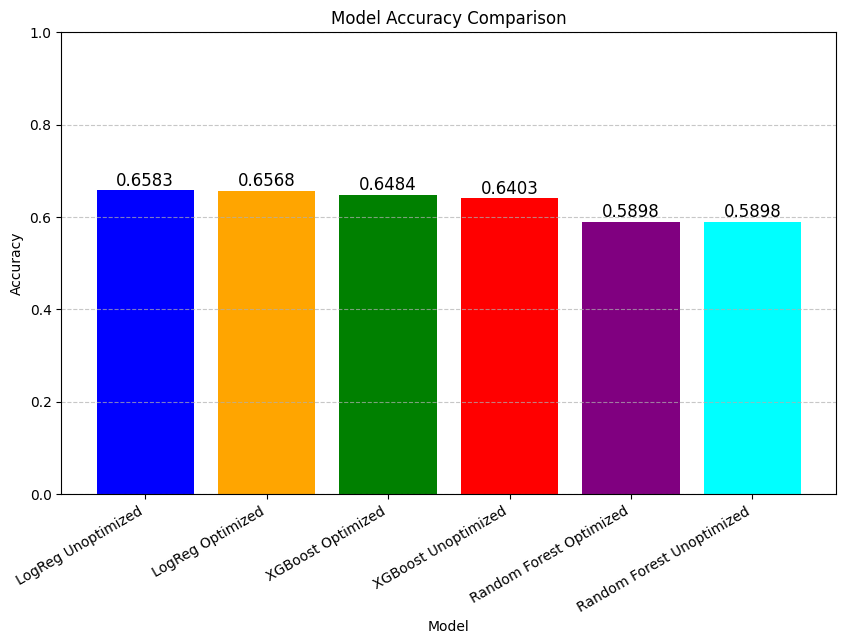

In [ ]:
accuracy_values = {
    "LogReg Optimized": lro,
    "LogReg Unoptimized": lru,
    "Random Forest Optimized": rfo,
    "Random Forest Unoptimized": rfu,
    "XGBoost Optimized": xgo,
    "XGBoost Unoptimized": xgu
}

# Sorting models by accuracy
accuracy_values = dict(sorted(accuracy_values.items(), key=lambda item: item[1], reverse=True))

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(accuracy_values.keys(), accuracy_values.values(), color=['blue', 'orange', 'green', 'red', 'purple', 'cyan'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30, ha='right')  # Rotate x labels for readability
plt.ylim(0, 1)  # Accuracy range
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on bars
for i, v in enumerate(accuracy_values.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=12)

plt.show()


In [ ]:
# Get feature importance from the logistic regression model
feature_importance_lr = best_lr.coef_[0]  # Coefficients for each word

# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Sort top positive and negative features
top_n = 20
sorted_idx = np.argsort(feature_importance_lr)

print("🔹 Top Positive Words (Contribute to Good Sentiment):")
print([feature_names[i] for i in sorted_idx[-top_n:]])

print("\n🔸 Top Negative Words (Contribute to Bad Sentiment):")
print([feature_names[i] for i in sorted_idx[:top_n]])


🔹 Top Positive Words (Contribute to Good Sentiment):
['pho', 'ihop', 'cpk', 'dennys', 'chinese', 'vons', 'mcdonalds', 'rudys', 'woodys', 'moby', 'panera', 'rustys', 'hana', 'palazzio', 'hyatt', 'aldos', 'longboards', 'starbucks', 'chase', 'view']

🔸 Top Negative Words (Contribute to Bad Sentiment):
['agave', 'reservation', 'gluten', 'cupcake', 'poke', 'mesa', 'delicious', 'amazing', 'popcorn', 'creative', 'cat', 'smoothie', 'oyster', 'pastry', 'blender', 'unique', 'lure', 'phenomenal', 'overrated', 'incredible']


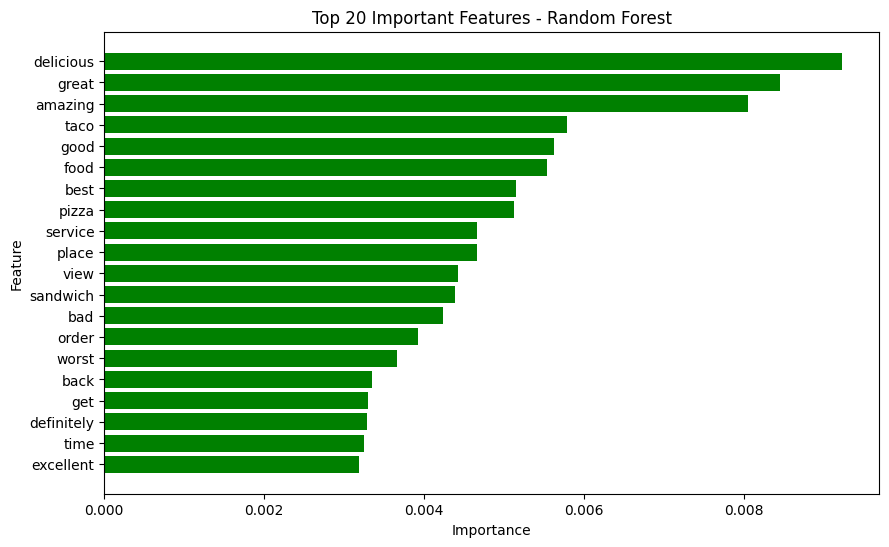

In [ ]:
# Get feature importance
feature_importance_rf = best_rf.feature_importances_

# Create DataFrame for visualization
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance_rf})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='green')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - Random Forest")
plt.gca().invert_yaxis()  # Highest at the top
plt.show()


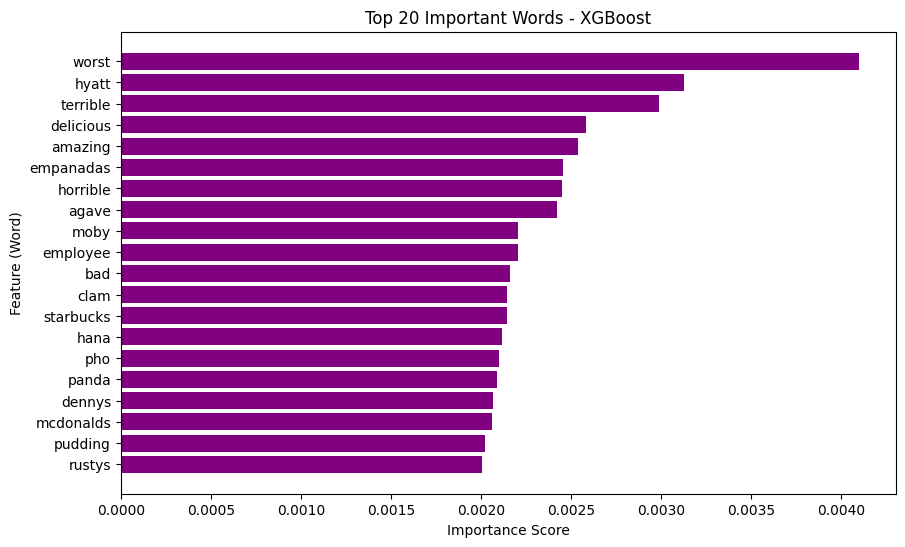

In [ ]:
from xgboost import plot_importance

feature_names = tfidf.get_feature_names_out()

xgb_importance = best_xgb.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple')
plt.xlabel("Importance Score")
plt.ylabel("Feature (Word)")
plt.title("Top 20 Important Words - XGBoost")
plt.gca().invert_yaxis()  # Highest at the top
plt.show()

**Premade models**

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to each review
df_balanced['vader_sentiment'] = df_balanced['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Show results
df_balanced[['text', 'vader_sentiment']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,vader_sentiment
0,pleasant experience quick trip santa barbara a...,0.8112
1,give 5 star yummy sushi 9 amazing got sashimi ...,0.9459
2,said website open walked 20 min get closed una...,-0.4588
3,didnt order black spaghetti scallopsyoure wron...,0.6908
4,came expecting great breakfast disappointed co...,0.7482


In [ ]:
def classify_vader_rating(score):
    if score > 0.85:
        return 2
    elif score < -0.2:
        return 0
    else:
        return 1


# Apply classification function to VADER sentiment scores
df_balanced['vader_rating'] = df_balanced['vader_sentiment'].apply(classify_vader_rating)
df_balanced.head()


,text,stars_y,review_count,is_open,sentimentByStar,vader_sentiment,vader_rating,sentiment_label
0,pleasant experience quick trip santa barbara a...,4.5,497,1,2,0.8112,1,2
1,give 5 star yummy sushi 9 amazing got sashimi ...,4.0,274,0,1,0.9459,2,1
2,said website open walked 20 min get closed una...,4.0,643,1,1,-0.4588,0,1
3,didnt order black spaghetti scallopsyoure wron...,4.5,1084,1,2,0.6908,1,2
4,came expecting great breakfast disappointed co...,4.0,761,1,1,0.7482,1,1


In [ ]:
sentiment_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}
df_balanced['sentiment_label'] = df_balanced['sentimentByStar'].astype(int)

# LogReg performance
logreg_predictions = best_lr.predict(tfidf.transform(df_balanced['text']))

# Convert LogReg numeric predictions to categorical labels
logreg_labels = pd.Series(logreg_predictions)

# Compare LogReg vs. True Labels
print("🔹 Logistic Regression Performance:")
print(classification_report(df_balanced['sentiment_label'], logreg_labels))
logreg_accuracy = accuracy_score(df_balanced['sentiment_label'], logreg_labels)

# Compare VADER vs. True Labels
print("\n🔹 VADER Sentiment Analysis Performance:")
print(classification_report(df_balanced['sentiment_label'], df_balanced['vader_rating']))
vader_accuracy = accuracy_score(df_balanced['sentiment_label'], df_balanced['vader_rating'])

# Create a comparison table
comparison_df = pd.DataFrame({
  'Actual Sentiment': df_balanced['sentiment_label'],
  'LogReg Prediction': logreg_labels,
  'VADER Prediction': df_balanced['vader_rating']
})

# Display accuracy scores
print(f"\nLogReg Accuracy: {logreg_accuracy:.4f}, VADER Accuracy: {vader_accuracy:.4f}")

# Show the first few rows for review
print("\n🔍 Sample Predictions:")
print(comparison_df.head(20))

🔹 Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.74      0.79      0.77     18065
           1       0.66      0.60      0.63     18065
           2       0.73      0.74      0.73     18065

    accuracy                           0.71     54195
   macro avg       0.71      0.71      0.71     54195
weighted avg       0.71      0.71      0.71     54195


🔹 VADER Sentiment Analysis Performance:
              precision    recall  f1-score   support

           0       0.67      0.20      0.31     18065
           1       0.31      0.26      0.28     18065
           2       0.40      0.75      0.52     18065

    accuracy                           0.40     54195
   macro avg       0.46      0.40      0.37     54195
weighted avg       0.46      0.40      0.37     54195


LogReg Accuracy: 0.7112, VADER Accuracy: 0.4027

🔍 Sample Predictions:
    Actual Sentiment  LogReg Prediction  VADER Prediction
0                  2            

In [ ]:
df.iloc[15]

,15
text,new owner turned double threat bad food bad se...
stars_y,4.0
review_count,128
is_open,1
sentimentByStar,1
vader_sentiment,-0.8625
vader_rating,Negative


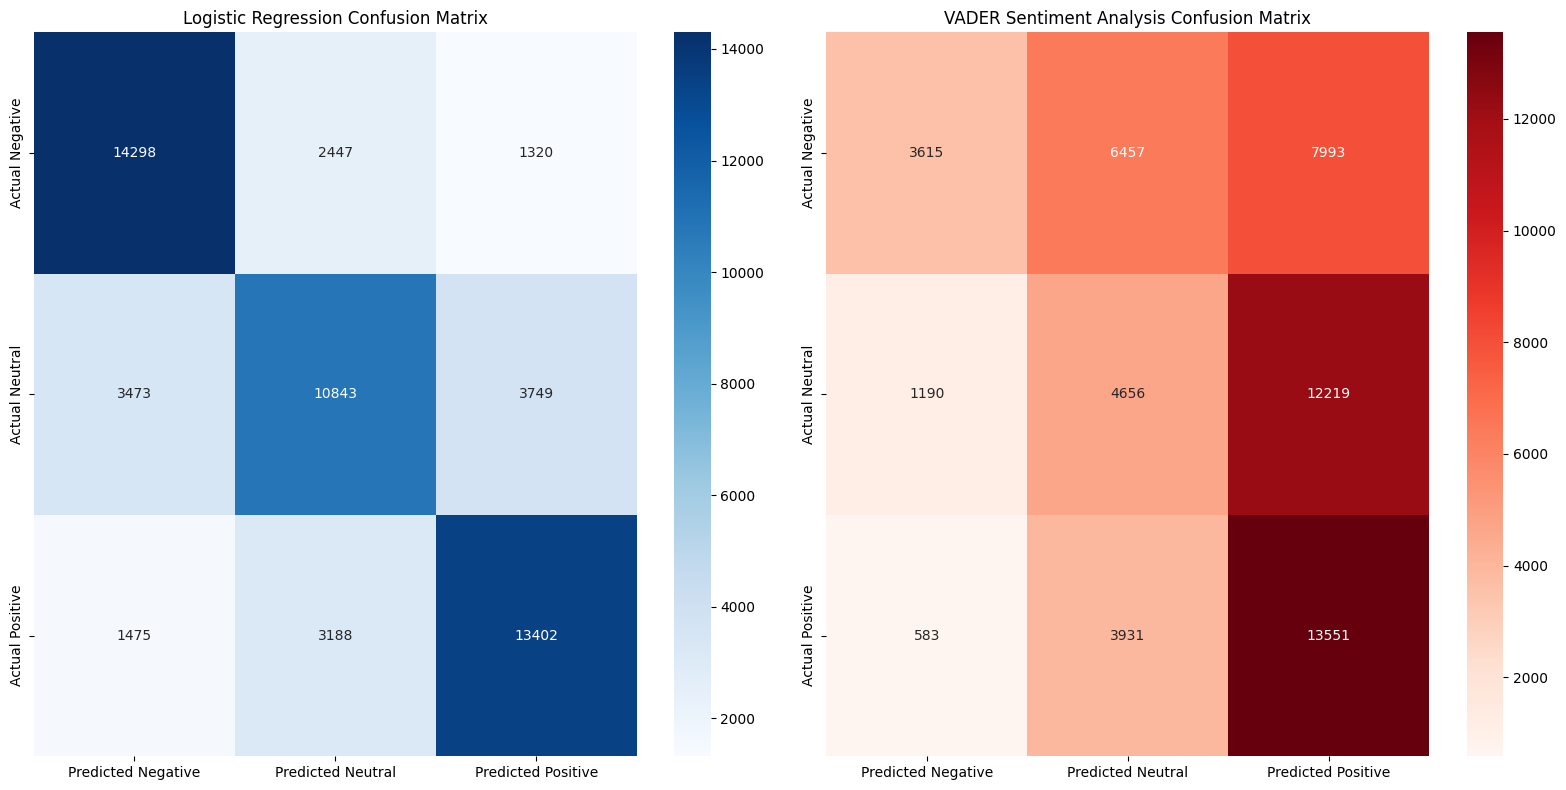

<ipython-input-127-cda77f3f6782>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="coolwarm")


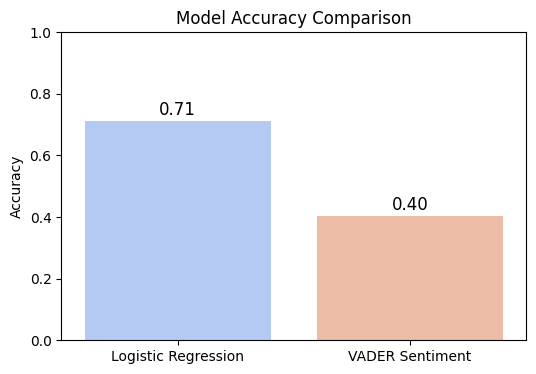

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Ensure sentiment mapping exists
sentiment_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Compute confusion matrices for LogReg and VADER
logreg_cm = confusion_matrix(df_balanced['sentiment_label'], logreg_labels, labels=[0, 1, 2])
vader_cm = confusion_matrix(df_balanced['sentiment_label'], df_balanced['vader_rating'], labels=[0, 1, 2])

# Convert to DataFrame for visualization
logreg_cm_df = pd.DataFrame(logreg_cm, index=["Actual Negative", "Actual Neutral", "Actual Positive"],
                            columns=["Predicted Negative", "Predicted Neutral", "Predicted Positive"])

vader_cm_df = pd.DataFrame(vader_cm, index=["Actual Negative", "Actual Neutral", "Actual Positive"],
                            columns=["Predicted Negative", "Predicted Neutral", "Predicted Positive"])

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(logreg_cm_df, annot=True, fmt='d', cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")

sns.heatmap(vader_cm_df, annot=True, fmt='d', cmap="Reds", ax=axes[1])
axes[1].set_title("VADER Sentiment Analysis Confusion Matrix")

plt.tight_layout()
plt.show()

# Plot model accuracy comparison
model_accuracies = {
    "Logistic Regression": logreg_accuracy,
    "VADER Sentiment": vader_accuracy
}

plt.figure(figsize=(6, 4))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="coolwarm")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Show accuracy values on bars
for i, v in enumerate(model_accuracies.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)

plt.show()
